In [8]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

import sklearn

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

In [77]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

np.random.seed(42)
n = 1000

# Генерируем признаки с разными масштабами и с выбросами
hours_per_week = np.random.exponential(scale=10, size=n).clip(2, 40)  # скошенное распределение
break_freq = np.random.lognormal(mean=-0.5, sigma=0.7, size=n).clip(0.1, 3.0)
sessions_per_week = np.random.poisson(lam=8, size=n).clip(1, 25)
task_completion_rate = np.random.beta(a=5, b=2, size=n)  # близко к нормальному, но с границами
forum_posts = np.random.negative_binomial(n=2, p=0.1, size=n).clip(0, 50)  # дискретное, скошенное
prev_course_score = np.random.normal(loc=65, scale=15, size=n).clip(30, 100)
device_type = np.random.choice([0, 1, 2], size=n)
is_weekend_learner = np.random.binomial(1, 0.35, size=n)

# Таргет — нелинейная комбинация признаков с шумом
# Добавляем взаимодействия, чтобы нормализация была критична
true_score = (
    0.3 * np.sqrt(hours_per_week) * 10
    + 0.2 * np.log1p(break_freq) * 15 * (1 + 0.3 * sessions_per_week / 10)
    + 0.25 * task_completion_rate * 60
    + 0.1 * np.log1p(forum_posts) * 8
    + 0.15 * (prev_course_score - 50) * 0.5
    - 2 * device_type  # штраф за устройство
    + 3 * is_weekend_learner
    + np.random.normal(0, 2, size=n)
).clip(0, 100)

df = pd.DataFrame({
    'hours_per_week': hours_per_week,
    'break_freq': break_freq,
    'sessions_per_week': sessions_per_week,
    'task_completion_rate': task_completion_rate,
    'forum_posts': forum_posts,
    'prev_course_score': prev_course_score,
    'device_type': device_type,
    'is_weekend_learner': is_weekend_learner,
    'final_project_score': true_score
})

# Сравним эффективность нормализации
X = df.drop(columns='final_project_score')
y = df['final_project_score']

for name, scaler in [('None', None), ('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler()), ('RobustScaler', RobustScaler())]:
    if scaler:
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X.values
        
#     scores = cross_val_score(MLPRegressor(), X_scaled, y, cv=5, scoring='r2')
#     scores = cross_val_score(KNeighborsRegressor(), X_scaled, y, cv=5, scoring='r2')
#     scores = cross_val_score(SVR(), X_scaled, y, cv=5, scoring='r2')
#     scores = cross_val_score(GradientBoostingRegressor(), X_scaled, y, cv=5, scoring='r2')
#     scores = cross_val_score(RandomForestRegressor(), X_scaled, y, cv=5, scoring='r2')
#     scores = cross_val_score(DecisionTreeRegressor(), X_scaled, y, cv=5, scoring='r2')
    scores = cross_val_score(LinearRegression(), X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
    print(f'{name:20s}: R2 = {scores.mean():.4f} (+/- {scores.std():.4f})')


None                : R2 = -1.8292 (+/- 0.0677)
StandardScaler      : R2 = -1.8292 (+/- 0.0677)
MinMaxScaler        : R2 = -1.8292 (+/- 0.0677)
RobustScaler        : R2 = -1.8292 (+/- 0.0677)


In [78]:
# df.to_csv('data/skill_spring.csv', index = False)

In [79]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

np.random.seed(42)
n = 2000

# 1. Генерируем сырые признаки (до нормализации) — с разными масштабами
delivery_time_min_raw = np.random.lognormal(mean=3.8, sigma=0.3, size=n).astype(int).clip(10, 120)
order_amount_raw = np.random.lognormal(mean=6.5, sigma=0.5, size=n).clip(200, 3000)
distance_km_raw = np.random.exponential(scale=5, size=n).clip(0.5, 20.0)
courier_rating_raw = np.random.uniform(3.0, 5.0, size=n)
courier_experience_raw = np.random.poisson(lam=18, size=n).clip(0, 36)
is_weekend_raw = np.random.binomial(1, 0.3, size=n)
is_rain_raw = np.random.binomial(1, 0.25, size=n)
num_items_raw = np.random.poisson(lam=4, size=n).clip(1, 10)

# 2. Нормализуем (StandardScaler)
raw_features = np.column_stack([
    delivery_time_min_raw,
    order_amount_raw,
    distance_km_raw,
    courier_rating_raw,
    courier_experience_raw,
    is_weekend_raw,
    is_rain_raw,
    num_items_raw
])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(raw_features)

# 3. Формируем таргет на основе НОРМАЛИЗОВАННЫХ признаков
#    Используем логистическую функцию с чёткими весами
logits = (
    1.2 * scaled_features[:, 0]   # delivery_time
    - 0.8 * scaled_features[:, 1] # order_amount
    + 0.9 * scaled_features[:, 2] # distance
    + 1.5 * scaled_features[:, 3] # courier_rating
    + 0.6 * scaled_features[:, 4] # courier_experience
    + 0.3 * scaled_features[:, 5] # is_weekend
    - 1.0 * scaled_features[:, 6] # is_rain
    + 0.4 * scaled_features[:, 7] # num_items
    + 0.5  # bias
)

prob = 1 / (1 + np.exp(-logits))
tip = (prob > 0.5).astype(int)

# 4. Собираем датасет из ИСХОДНЫХ (ненорализованных) признаков + таргет
df = pd.DataFrame({
    'delivery_time_min': delivery_time_min_raw,
    'order_amount': order_amount_raw,
    'distance_km': distance_km_raw,
    'courier_rating': courier_rating_raw,
    'courier_experience': courier_experience_raw,
    'is_weekend': is_weekend_raw,
    'is_rain': is_rain_raw,
    'num_items': num_items_raw,
    'tip': tip
})

# Проверка: сравним logistic regression на сырых и нормализованных данных
X_raw = df.drop(columns='tip')
y = df['tip']

print("=== Logistic Regression на сырых данных ===")
scores_raw = cross_val_score(LogisticRegression(max_iter=1000), X_raw, y, cv=5, scoring='accuracy')
print(f"Accuracy = {scores_raw.mean():.4f} (+/- {scores_raw.std():.4f})")

print("\n=== Logistic Regression на нормализованных данных ===")
X_scaled = scaler.fit_transform(X_raw)
scores_scaled = cross_val_score(LogisticRegression(max_iter=1000), X_scaled, y, cv=5, scoring='accuracy')
print(f"Accuracy = {scores_scaled.mean():.4f} (+/- {scores_scaled.std():.4f})")


=== Logistic Regression на сырых данных ===
Accuracy = 0.9875 (+/- 0.0071)

=== Logistic Regression на нормализованных данных ===
Accuracy = 0.9900 (+/- 0.0067)


In [90]:
df

,delivery_time_min,order_amount,distance_km,courier_rating,courier_experience,is_weekend,is_rain,num_items,tip
0,51,474.570822,3.318117,4.246345,17,0,1,5,0
1,42,618.774349,0.500000,3.148857,16,1,1,2,0
2,54,447.550795,17.960831,4.007384,21,0,1,6,1
3,70,570.218280,3.649164,3.365250,16,0,0,4,1
4,41,258.060142,4.762003,4.147950,16,0,0,3,1
...,...,...,...,...,...,...,...,...,...
1995,61,674.673446,3.441456,4.010056,18,0,0,4,1
1996,44,235.354783,0.841162,3.060993,18,0,0,5,0
1997,34,566.711920,1.010109,3.263621,29,0,1,4,0
1998,42,1512.756977,2.271026,4.773179,22,0,1,6,0


In [84]:
X = df.drop(columns=['tip'])
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [87]:
print('accuracy =', accuracy_score(y_test, y_pred))
print('precision =', precision_score(y_test, y_pred))
print('recall =', recall_score(y_test, y_pred))
print('f1 =', f1_score(y_test, y_pred))

accuracy = 0.668
precision = 0.7123745819397993
recall = 0.726962457337884
f1 = 0.7195945945945945


In [89]:
X_train_scaled = (X_train - X_train.mean())/X_train.std()
X_test_scaled  = (X_test - X_train.mean())/X_train.std()

model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('accuracy =', accuracy_score(y_test, y_pred))
print('precision =', precision_score(y_test, y_pred))
print('recall =', recall_score(y_test, y_pred))
print('f1 =', f1_score(y_test, y_pred))

accuracy = 0.892
precision = 0.9134948096885813
recall = 0.9010238907849829
f1 = 0.9072164948453608


In [91]:
# df.to_csv('data/quick_bite.csv', index = False)

In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 5000

# 1. Районы (12 штук) с неявным порядком по престижности
districts = [
    'Центральный', 'Парковый', 'Речной', 'Холмогорский',
    'Западный', 'Восточный', 'Северный', 'Южный',
    'Новостройки', 'Привокзальный', 'Заречный', 'Промышленный'
]
# Чем выше индекс в списке — тем менее престижный район (в среднем)
district_values = np.random.choice(districts, size=n_samples)

# 2. Тип стен (4 значения)
wall_types = ['кирпич', 'панель', 'монолит', 'дерево']
wall_values = np.random.choice(wall_types, size=n_samples, p=[0.35, 0.30, 0.25, 0.10])

# 3. Улицы (65 штук) — сгенерируем как "Улица_0" ... "Улица_64"
streets = [f'Улица_{i}' for i in range(65)]
# У каждой улицы свой базовый уровень цены (шумный центр — дешевле, тихие переулки — дороже)
street_base_price = {
    street: 80 + 30 * np.sin(i) + 10 * np.cos(i * 0.7) + np.random.uniform(-10, 10)
    for i, street in enumerate(streets)
}
street_values = np.random.choice(streets, size=n_samples)

# 4. Таргет: price_per_sqm
price_per_sqm = np.zeros(n_samples)

for i in range(n_samples):
    district = district_values[i]
    wall = wall_values[i]
    street = street_values[i]

    # Базовый уровень для района
    district_idx = districts.index(district)
    base_district = 120 - district_idx * 7 + np.random.normal(0, 8)

    # Влияние типа стен
    if wall == 'кирпич':
        wall_effect = 25
    elif wall == 'монолит':
        wall_effect = 15
    elif wall == 'панель':
        wall_effect = -10
    else:  # дерево
        wall_effect = -25

    # Влияние улицы (берем из словаря с небольшим шумом)
    street_effect = street_base_price[street] + np.random.normal(0, 12)

    # Итоговая цена
    price = base_district + wall_effect + street_effect * 0.5 + np.random.normal(0, 15)
    price_per_sqm[i] = max(40, min(280, round(price, 1)))

# Собираем DataFrame
df = pd.DataFrame({
    'district': district_values,
    'wall_type': wall_values,
    'street': street_values,
    'price_per_sqm': price_per_sqm
})

print(df.head())
print(f'\nФорма датасета: {df.shape}')
print(f'\nУникальных районов: {df["district"].nunique()}')
print(f'Уникальных типов стен: {df["wall_type"].nunique()}')
print(f'Уникальных улиц: {df["street"].nunique()}')
print(f'\nДиапазон таргета: {df["price_per_sqm"].min():.1f} – {df["price_per_sqm"].max():.1f}')


       district wall_type    street  price_per_sqm
0      Северный    панель  Улица_37           97.3
1  Холмогорский    дерево  Улица_40          121.4
2      Заречный    панель  Улица_13           61.3
3         Южный    кирпич  Улица_50          137.1
4      Западный    кирпич  Улица_64          170.8

Форма датасета: (5000, 4)

Уникальных районов: 12
Уникальных типов стен: 4
Уникальных улиц: 65

Диапазон таргета: 40.0 – 239.4


<Axes: xlabel='district', ylabel='price_per_sqm'>

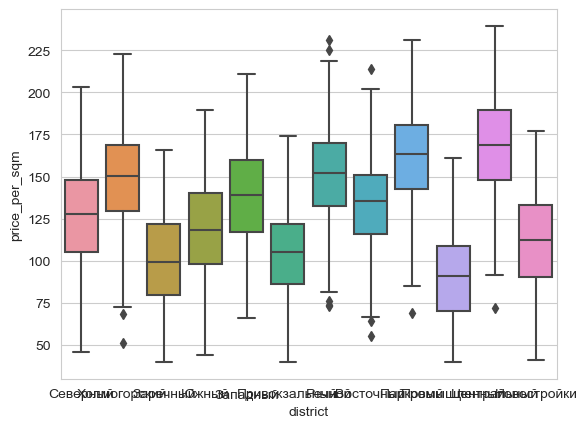

In [9]:
sns.boxplot(data = df, x = 'district', y = 'price_per_sqm')

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 5000

# 1. Районы (12 штук) с неявным порядком по престижности
districts = [
    'Исторический центр', 'Центр', 'Окраины'
]
# Чем выше индекс в списке — тем менее престижный район (в среднем)
district_values = np.random.choice(districts, size=n_samples)

# 2. Тип стен (4 значения)
wall_types = ['кирпич', 'панель', 'монолит', 'дерево']
wall_values = np.random.choice(wall_types, size=n_samples, p=[0.35, 0.30, 0.25, 0.10])

# 3. Улицы (65 штук) — сгенерируем как "Улица_0" ... "Улица_64"
streets = [f'Улица_{i}' for i in range(65)]
# У каждой улицы свой базовый уровень цены (шумный центр — дешевле, тихие переулки — дороже)
street_base_price = {
    street: 80 + 30 * np.sin(i) + 10 * np.cos(i * 0.7) + np.random.uniform(-10, 10)
    for i, street in enumerate(streets)
}
street_values = np.random.choice(streets, size=n_samples)

# 4. Таргет: price_per_sqm
price_per_sqm = np.zeros(n_samples)

for i in range(n_samples):
    district = district_values[i]
    wall = wall_values[i]
    street = street_values[i]

    # Базовый уровень для района
    district_idx = districts.index(district)
    base_district = 120 - district_idx * 50 + np.random.normal(0, 8)

    # Влияние типа стен
    if wall == 'кирпич':
        wall_effect = 25
    elif wall == 'монолит':
        wall_effect = 15
    elif wall == 'панель':
        wall_effect = -10
    else:  # дерево
        wall_effect = -25

    # Влияние улицы (берем из словаря с небольшим шумом)
    street_effect = street_base_price[street] + np.random.normal(0, 12)
    
    
#     print(street)

    # Итоговая цена
    price = base_district + wall_effect + street_effect * 0.5 + np.random.normal(0, 15)
    price_per_sqm[i] = max(40, min(280, round(price, 1)))

# Собираем DataFrame
df = pd.DataFrame({
    'district': district_values,
    'wall_type': wall_values,
    'street': street_values,
    'price_per_sqm': price_per_sqm
})

print(df.head())
print(f'\nФорма датасета: {df.shape}')
print(f'\nУникальных районов: {df["district"].nunique()}')
print(f'Уникальных типов стен: {df["wall_type"].nunique()}')
print(f'Уникальных улиц: {df["street"].nunique()}')
print(f'\nДиапазон таргета: {df["price_per_sqm"].min():.1f} – {df["price_per_sqm"].max():.1f}')


             district wall_type    street  price_per_sqm
0             Окраины    кирпич   Улица_8           98.0
1  Исторический центр    кирпич  Улица_35          152.8
2             Окраины   монолит  Улица_39           59.4
3             Окраины    панель  Улица_23           40.0
4  Исторический центр   монолит  Улица_47          163.0

Форма датасета: (5000, 4)

Уникальных районов: 3
Уникальных типов стен: 4
Уникальных улиц: 65

Диапазон таргета: 40.0 – 242.5


<Axes: xlabel='district', ylabel='price_per_sqm'>

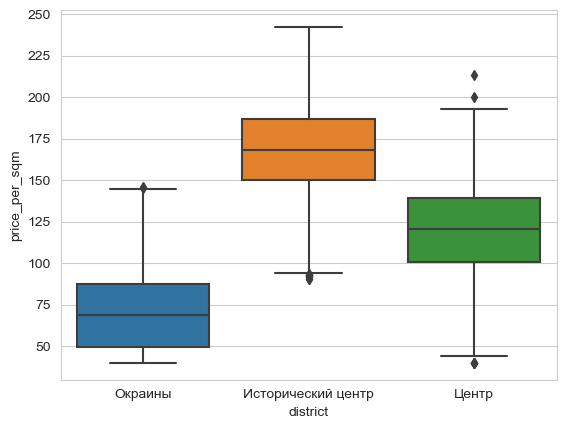

In [22]:
sns.boxplot(data = df, x = 'district', y = 'price_per_sqm')

In [23]:
# df.to_csv('data/house_in_window.csv', index = False)

In [31]:
import pandas as pd
import numpy as np

SEED = 42

def generate_bistro_data(n_samples: int = 20000, random_state: int = SEED) -> pd.DataFrame:
    """
    Генерирует синтетический датасет для задачи бинарной классификации рейтинга.
    Признаки: city_district (Ordinal), cuisine_type (One-Hot), restaurant_name (Target),
    avg_check (числовой). Таргет: high_rating (0/1).
    """
    np.random.seed(random_state)

    # 1. Районы с неявным порядком престижности (для Ordinal Encoding)
    # Список от самого престижного (высокая вероятность high_rating) до наименее престижного
    districts_order = [
        'Центр-1', 'Центр-2', 'Деловой центр', 'Торговый', 'Парковый',
        'Студенческий', 'Спальный-Запад', 'Спальный-Юг', 'Спальный-Восток',
        'Вокзальный', 'Рынок', 'Промышленный-Юг'
    ]
    # Вероятность high_rating для районов (убывает)
    district_proba = {
        'Центр-1': 0.75, 'Центр-2': 0.70, 'Деловой центр': 0.68,
        'Торговый': 0.60, 'Парковый': 0.55,
        'Студенческий': 0.45, 'Спальный-Запад': 0.40, 'Спальный-Юг': 0.38,
        'Спальный-Восток': 0.35, 'Вокзальный': 0.28, 'Рынок': 0.22,
        'Промышленный-Юг': 0.18
    }

    # 2. Типы кухни — просто равномерное распределение
    cuisine_types = ['русская', 'итальянская', 'азиатская', 'фастфуд']
    # Но у разных кухонь — разная популярность у посетителей
    cuisine_boost = {
        'итальянская': 0.10,
        'азиатская': 0.05,
        'русская': 0.0,
        'фастфуд': -0.10
    }

    # 3. Названия ресторанов — 70 уникальных
    rest_names = [
        'У Егора', 'Пирожок на углу', 'БургерХаус', 'СушиВок', 'Пельмения',
        'Кофе-Брейк', 'Добрая столовая', 'Китайский квартал', 'Итальянский дворик',
        'Блинная №1', 'Чайхана', 'Узбечка', 'Шаурма-Экспресс', 'Пицца-Прайм',
        'Грузинский дом', 'Хинкальная', 'Студенческая столовая', 'Вок-Вок',
        'Русский аппетит', 'Деловой ланч', 'Суп-Суп', 'Салатный бар',
        'Мясной рай', 'Рыбный день', 'Вегетарианский уголок', 'Халяль-гриль',
        'Паста-Мания', 'Рис и лапша', 'Лапшичная', 'Кулинария',
        'Бутербродная', 'На углу', 'Перекусич', 'Быстро и вкусно',
        'Сытый студент', 'Поварёшка', 'Трапеза', 'Сковородка',
        'Борщ-меню', 'Котлетная', 'Кебаб-хаус', 'Фалафельная',
        'Мама-печёт', 'Бабушкины пирожки', 'Сладкая жизнь', 'Кондитерская-Кофе',
        'Капуччино-Бар', 'Утренний кофе', 'Обед-Бокс', 'Ларек с хот-догами',
        'Вечерний свет', 'Горячий хлеб', 'Кренделёк', 'Пончик-хаус',
        'Корн-дог', 'Фиш-н-чипс', 'Такос-Амигос', 'Буррито-Кинг',
        'Рамен-тайм', 'Том-ям-бар', 'Луковые кольца', 'Морс-бар',
        'Квасная лавка', 'Мороженое-Софт', 'Пекарня у дома', 'Хлеб и масло',
        'Вареники', 'Сырная тарелка', 'Пивной ресторан', 'Винный погреб'
    ][:70]

    # У каждого названия — своя «известность» (score), влияющая на рейтинг
    # Бренды с узнаваемыми именами получают бонус, дешёвые/странные — штраф
    name_score = {
        'У Егора': 0.15, 'Пирожок на углу': 0.0, 'БургерХаус': -0.05,
        'СушиВок': 0.08, 'Пельмения': -0.02, 'Кофе-Брейк': 0.05,
        'Добрая столовая': -0.10, 'Китайский квартал': 0.12,
        'Итальянский дворик': 0.20, 'Пицца-Прайм': 0.18,
        'Хинкальная': 0.10, 'Студенческая столовая': -0.25,
        'Русский аппетит': 0.06, 'Деловой ланч': 0.02,
        'Вегетарианский уголок': -0.08, 'Халяль-гриль': 0.07,
        'Паста-Мания': 0.15, 'Китайский квартал': 0.12,
        'Кулинария': -0.12, 'Сытый студент': -0.18
    }
    # Для остальных — от -0.15 до 0.10
    default_name_score = np.random.uniform(-0.15, 0.10, size=len(rest_names))
    for i, name in enumerate(rest_names):
        if name not in name_score:
            name_score[name] = default_name_score[i]

    # Генерация данных
    districts = np.random.choice(districts_order, size=n_samples)
    cuisines = np.random.choice(cuisine_types, size=n_samples)
    names = np.random.choice(rest_names, size=n_samples)
    avg_checks = np.random.randint(150, 2501, size=n_samples)  # 150-2500 руб

    # Собираем DataFrame
    df = pd.DataFrame({
        'city_district': districts,
        'cuisine_type': cuisines,
        'restaurant_name': names,
        'avg_check': avg_checks
    })

    # Вычисляем базовую вероятность high_rating для каждого образца
    # Используем логистическую функцию от линейной комбинации

    # Базовый bias (средняя вероятность)
    bias = -0.5

    # Вес для районного фактора
    district_effect = np.array([district_proba[d] for d in districts])
    district_logit = np.log(district_effect / (1 - district_effect + 1e-10))  # обратная logit

    # Вклад типа кухни
    cuisine_effect = np.array([cuisine_boost[c] for c in cuisines])

    # Вклад названия
    name_effect = np.array([name_score[n] for n in names])

    # Вклад среднего чека (пусть высокий средний чек отрицательно коррелирует с рейтингом?
    # Решим: умеренный чек — золотая середина, фастфуд дешёвый — часто низкий рейтинг,
    # очень дорогой — ожидания выше, тоже риски)
    # Поэтому avg_check входит как парабола: -0.0003*(avg_check - 1000)^2 (нормализовано)
    check_effect = -0.0000015 * (avg_checks - 1000) ** 2

    # Собираем logit
    logit = bias + district_logit + cuisine_effect + name_effect + check_effect
    # Добавим шум
    logit += np.random.normal(0, 0.5, size=n_samples)

    # Превращаем в вероятности
    prob = 1 / (1 + np.exp(-logit))

    # Бинаризируем
    df['high_rating'] = (np.random.random(n_samples) < prob).astype(int)

    return df

# Пример запуска
if __name__ == '__main__':
    df = generate_bistro_data(20000)
    print(df.head(10))
    print(f'\nРаспределение таргета:')
    print(df['high_rating'].value_counts(normalize=True))
    print(f'\nУникальных районов: {df["city_district"].nunique()}')
    print(f'Уникальных типов кухни: {df["cuisine_type"].nunique()}')
    print(f'Уникальных названий: {df["restaurant_name"].nunique()}')
    print(f'Диапазон avg_check: {df["avg_check"].min()} - {df["avg_check"].max()}')


     city_district cuisine_type        restaurant_name  avg_check  high_rating
0      Спальный-Юг  итальянская                Чайхана       1431            0
1          Центр-1      русская               Морс-бар        964            0
2  Промышленный-Юг      русская             Фиш-н-чипс       1419            0
3      Спальный-Юг    азиатская              Обед-Бокс        389            1
4      Спальный-Юг      фастфуд             Хинкальная       1301            0
5            Рынок  итальянская     Итальянский дворик       1887            0
6    Деловой центр  итальянская              Перекусич        425            0
7          Центр-1  итальянская          Сытый студент       2404            0
8      Спальный-Юг  итальянская              Борщ-меню       1725            0
9    Деловой центр      русская  Вегетарианский уголок        982            1

Распределение таргета:
0    0.75535
1    0.24465
Name: high_rating, dtype: float64

Уникальных районов: 12
Уникальных типов кухни:

In [32]:
df['restaurant_name'].nunique()

70

In [33]:
df

,city_district,cuisine_type,restaurant_name,avg_check,high_rating
0,Спальный-Юг,итальянская,Чайхана,1431,0
1,Центр-1,русская,Морс-бар,964,0
2,Промышленный-Юг,русская,Фиш-н-чипс,1419,0
3,Спальный-Юг,азиатская,Обед-Бокс,389,1
4,Спальный-Юг,фастфуд,Хинкальная,1301,0
...,...,...,...,...,...
19995,Спальный-Восток,азиатская,Буррито-Кинг,1102,0
19996,Спальный-Юг,азиатская,Обед-Бокс,2056,0
19997,Парковый,итальянская,БургерХаус,1310,0
19998,Парковый,итальянская,Сладкая жизнь,2040,1


In [34]:
import pandas as pd
import numpy as np

SEED = 42

def generate_bistro_margin_data(n_samples: int = 20000, random_state: int = SEED) -> pd.DataFrame:
    """
    Генерирует синтетический датасет для задачи бинарной классификации.
    Признаки:
    - rating (ordinal) — рейтинг заведения на Яндекс.Картах: 1-5 звезд.
    - cuisine_type (nominal) — тип кухни: one-hot encoding.
    - restaurant_name (high cardinality) — название: target encoding.
    - avg_check (числовой) — средний чек, рубли.
    - high_margin (таргет) — 1, если маржинальность > 5%, иначе 0.
    """
    np.random.seed(random_state)

    # 1. Рейтинг — настоящая ordinal переменная с естественным порядком
    # Более высокий рейтинг положительно влияет на маржинальность (можно установить выше цены)
    rating_values = [1, 2, 3, 4, 5]
    # Вероятность high_margin для каждого рейтинга
    rating_margin_proba = {
        1: 0.10,    # Однозвёздочные — почти всегда убыточны
        2: 0.20,    # Две звезды — редко прибыльны
        3: 0.40,    # Середнячки — шанс 50/50
        4: 0.65,    # Хороший рейтинг — чаще прибыльны
        5: 0.80     # Отличный рейтинг — почти всегда высокая маржа
    }

    # 2. Типы кухни — без изменений (но с новым влиянием на маржу)
    cuisine_types = ['русская', 'итальянская', 'азиатская', 'фастфуд']
    # Влияние на маржинальность (дополнительный логит)
    cuisine_boost = {
        'итальянская': 0.30,   # Итальянская — премиум, маржа выше
        'азиатская': 0.15,     # Азиатская — популярна, хорошая маржа
        'русская': -0.05,      # Русская — много конкурентов, маржа ниже
        'фастфуд': -0.30       # Фастфуд — демпинг, маржа низкая
    }

    # 3. Названия ресторанов — те же 70 штук, но с новым влиянием
    rest_names = [
        'У Егора', 'Пирожок на углу', 'БургерХаус', 'СушиВок', 'Пельмения',
        'Кофе-Брейк', 'Добрая столовая', 'Китайский квартал', 'Итальянский дворик',
        'Блинная №1', 'Чайхана', 'Узбечка', 'Шаурма-Экспресс', 'Пицца-Прайм',
        'Грузинский дом', 'Хинкальная', 'Студенческая столовая', 'Вок-Вок',
        'Русский аппетит', 'Деловой ланч', 'Суп-Суп', 'Салатный бар',
        'Мясной рай', 'Рыбный день', 'Вегетарианский уголок', 'Халяль-гриль',
        'Паста-Мания', 'Рис и лапша', 'Лапшичная', 'Кулинария',
        'Бутербродная', 'На углу', 'Перекусич', 'Быстро и вкусно',
        'Сытый студент', 'Поварёшка', 'Трапеза', 'Сковородка',
        'Борщ-меню', 'Котлетная', 'Кебаб-хаус', 'Фалафельная',
        'Мама-печёт', 'Бабушкины пирожки', 'Сладкая жизнь', 'Кондитерская-Кофе',
        'Капуччино-Бар', 'Утренний кофе', 'Обед-Бокс', 'Ларек с хот-догами',
        'Вечерний свет', 'Горячий хлеб', 'Кренделёк', 'Пончик-хаус',
        'Корн-дог', 'Фиш-н-чипс', 'Такос-Амигос', 'Буррито-Кинг',
        'Рамен-тайм', 'Том-ям-бар', 'Луковые кольца', 'Морс-бар',
        'Квасная лавка', 'Мороженое-Софт', 'Пекарня у дома', 'Хлеб и масло',
        'Вареники', 'Сырная тарелка', 'Пивной ресторан', 'Винный погреб'
    ][:70]

    # Эффект названия на маржинальность (узнаваемость бренда позволяет держать цены)
    name_score = {
        'У Егора': 0.10, 'Пирожок на углу': -0.05, 'БургерХаус': -0.10,
        'СушиВок': 0.15, 'Пельмения': -0.08, 'Кофе-Брейк': 0.05,
        'Добрая столовая': -0.20, 'Китайский квартал': 0.18,
        'Итальянский дворик': 0.30, 'Пицца-Прайм': 0.25,
        'Хинкальная': 0.12, 'Студенческая столовая': -0.35,
        'Русский аппетит': 0.08, 'Деловой ланч': 0.02,
        'Вегетарианский уголок': -0.15, 'Халяль-гриль': 0.10,
        'Паста-Мания': 0.22, 'Кулинария': -0.18, 'Сытый студент': -0.25,
        'Пивной ресторан': 0.35, 'Винный погреб': 0.40  # Алкоголь — высокая маржа!
    }
    default_name_score = np.random.uniform(-0.20, 0.15, size=len(rest_names))
    for i, name in enumerate(rest_names):
        if name not in name_score:
            name_score[name] = default_name_score[i]

    # Генерация данных
    ratings = np.random.choice(rating_values, size=n_samples, 
                                p=[0.05, 0.10, 0.30, 0.35, 0.20])  # больше троек и четвёрок
    cuisines = np.random.choice(cuisine_types, size=n_samples)
    names = np.random.choice(rest_names, size=n_samples)
    avg_checks = np.random.randint(150, 2501, size=n_samples)

    df = pd.DataFrame({
        'rating': ratings,
        'cuisine_type': cuisines,
        'restaurant_name': names,
        'avg_check': avg_checks
    })

    # Вычисляем logit для high_margin
    bias = -1.2  # базовый

    # Вклад рейтинга — ordinal: преобразуем probability в logit
    rating_effect = np.array([np.log(rating_margin_proba[r] / (1 - rating_margin_proba[r] + 1e-10)) for r in ratings])

    # Вклад кухни
    cuisine_effect = np.array([cuisine_boost[c] for c in cuisines])

    # Вклад названия
    name_effect = np.array([name_score[n] for n in names])

    # Вклад среднего чека: нелинейный (оптимум маржи — не слишком дёшево и не слишком дорого)
    # Нормализуем: пусть пик маржинальности при avg_check ≈ 1200
    check_effect = -0.000002 * (avg_checks - 1200) ** 2

    logit = bias + rating_effect + cuisine_effect + name_effect + check_effect
    logit += np.random.normal(0, 0.4, size=n_samples)  # шум поменьше

    prob = 1 / (1 + np.exp(-logit))

    # Таргет: высокая маржинальность (> 5%)
    df['high_margin'] = (np.random.random(n_samples) < prob).astype(int)

    return df

if __name__ == '__main__':
    df = generate_bistro_margin_data(20000)
    print(df.head(10))
    print(f'\nРаспределение таргета (high_margin):')
    print(df['high_margin'].value_counts(normalize=True))
    print(f'\nРаспределение рейтинга:')
    print(df['rating'].value_counts(normalize=True).sort_index())
    print(f'\nСвязь рейтинга и маржинальности:')
    print(df.groupby('rating')['high_margin'].mean())
    print(f'\nПризнаки: {list(df.columns)}')


   rating cuisine_type restaurant_name  avg_check  high_margin
0       4  итальянская    Горячий хлеб       2364            0
1       3    азиатская    Хлеб и масло        321            0
2       1  итальянская      Кофе-Брейк        348            0
3       5  итальянская     Пицца-Прайм       2247            1
4       4      фастфуд       Лапшичная       1615            0
5       4  итальянская    Халяль-гриль        479            1
6       4    азиатская         Вок-Вок        443            0
7       2      фастфуд         СушиВок       2477            0
8       3      русская    Такос-Амигос        513            0
9       2    азиатская       Кренделёк        303            0

Распределение таргета (high_margin):
0    0.8137
1    0.1863
Name: high_margin, dtype: float64

Распределение рейтинга:
1    0.04945
2    0.10105
3    0.30025
4    0.34975
5    0.19950
Name: rating, dtype: float64

Связь рейтинга и маржинальности:
rating
1    0.017189
2    0.040079
3    0.103081
4    0.22

In [35]:
import pandas as pd
import numpy as np

SEED = 42

def generate_bistro_margin_data(n_samples: int = 20000, random_state: int = SEED) -> pd.DataFrame:
    """
    Генерирует синтетический датасет для задачи бинарной классификации.
    Признаки:
    - rating (ordinal) — рейтинг заведения на Яндекс.Картах: 1-5 звезд.
    - cuisine_type (nominal) — тип кухни: one-hot encoding.
    - restaurant_name (high cardinality) — название: target encoding.
    - avg_check (числовой) — средний чек, рубли.
    - high_margin (таргет) — 1, если маржинальность > 5%, иначе 0.
    """
    np.random.seed(random_state)

    # 1. Рейтинг — настоящая ordinal переменная с естественным порядком
    # Более высокий рейтинг положительно влияет на маржинальность (можно установить выше цены)
    rating_values = ['Одна звезда', 'Две звезды', 'Три звезды', 'Четыре звезды', 'Пять звезд']
    # Вероятность high_margin для каждого рейтинга
    rating_margin_proba = {
        'Одна звезда': 0.10,    # Однозвёздочные — почти всегда убыточны
        'Две звезды': 0.20,    # Две звезды — редко прибыльны
        'Три звезды': 0.40,    # Середнячки — шанс 50/50
        'Четыре звезды': 0.65,    # Хороший рейтинг — чаще прибыльны
        'Пять звезд': 0.80     # Отличный рейтинг — почти всегда высокая маржа
    }

    # 2. Типы кухни — без изменений (но с новым влиянием на маржу)
    cuisine_types = ['русская', 'итальянская', 'азиатская', 'фастфуд']
    # Влияние на маржинальность (дополнительный логит)
    cuisine_boost = {
        'итальянская': 0.30,   # Итальянская — премиум, маржа выше
        'азиатская': 0.15,     # Азиатская — популярна, хорошая маржа
        'русская': -0.05,      # Русская — много конкурентов, маржа ниже
        'фастфуд': -0.30       # Фастфуд — демпинг, маржа низкая
    }

    # 3. Названия ресторанов — те же 70 штук, но с новым влиянием
    rest_names = [
        'У Егора', 'Пирожок на углу', 'БургерХаус', 'СушиВок', 'Пельмения',
        'Кофе-Брейк', 'Добрая столовая', 'Китайский квартал', 'Итальянский дворик',
        'Блинная №1', 'Чайхана', 'Узбечка', 'Шаурма-Экспресс', 'Пицца-Прайм',
        'Грузинский дом', 'Хинкальная', 'Студенческая столовая', 'Вок-Вок',
        'Русский аппетит', 'Деловой ланч', 'Суп-Суп', 'Салатный бар',
        'Мясной рай', 'Рыбный день', 'Вегетарианский уголок', 'Халяль-гриль',
        'Паста-Мания', 'Рис и лапша', 'Лапшичная', 'Кулинария',
        'Бутербродная', 'На углу', 'Перекусич', 'Быстро и вкусно',
        'Сытый студент', 'Поварёшка', 'Трапеза', 'Сковородка',
        'Борщ-меню', 'Котлетная', 'Кебаб-хаус', 'Фалафельная',
        'Мама-печёт', 'Бабушкины пирожки', 'Сладкая жизнь', 'Кондитерская-Кофе',
        'Капуччино-Бар', 'Утренний кофе', 'Обед-Бокс', 'Ларек с хот-догами',
        'Вечерний свет', 'Горячий хлеб', 'Кренделёк', 'Пончик-хаус',
        'Корн-дог', 'Фиш-н-чипс', 'Такос-Амигос', 'Буррито-Кинг',
        'Рамен-тайм', 'Том-ям-бар', 'Луковые кольца', 'Морс-бар',
        'Квасная лавка', 'Мороженое-Софт', 'Пекарня у дома', 'Хлеб и масло',
        'Вареники', 'Сырная тарелка', 'Пивной ресторан', 'Винный погреб'
    ][:70]

    # Эффект названия на маржинальность (узнаваемость бренда позволяет держать цены)
    name_score = {
        'У Егора': 0.10, 'Пирожок на углу': -0.05, 'БургерХаус': -0.10,
        'СушиВок': 0.15, 'Пельмения': -0.08, 'Кофе-Брейк': 0.05,
        'Добрая столовая': -0.20, 'Китайский квартал': 0.18,
        'Итальянский дворик': 0.30, 'Пицца-Прайм': 0.25,
        'Хинкальная': 0.12, 'Студенческая столовая': -0.35,
        'Русский аппетит': 0.08, 'Деловой ланч': 0.02,
        'Вегетарианский уголок': -0.15, 'Халяль-гриль': 0.10,
        'Паста-Мания': 0.22, 'Кулинария': -0.18, 'Сытый студент': -0.25,
        'Пивной ресторан': 0.35, 'Винный погреб': 0.40  # Алкоголь — высокая маржа!
    }
    default_name_score = np.random.uniform(-0.20, 0.15, size=len(rest_names))
    for i, name in enumerate(rest_names):
        if name not in name_score:
            name_score[name] = default_name_score[i]

    # Генерация данных
    ratings = np.random.choice(rating_values, size=n_samples, 
                                p=[0.05, 0.10, 0.30, 0.35, 0.20])  # больше троек и четвёрок
    cuisines = np.random.choice(cuisine_types, size=n_samples)
    names = np.random.choice(rest_names, size=n_samples)
    avg_checks = np.random.randint(150, 2501, size=n_samples)

    df = pd.DataFrame({
        'rating': ratings,
        'cuisine_type': cuisines,
        'restaurant_name': names,
        'avg_check': avg_checks
    })

    # Вычисляем logit для high_margin
    bias = -1.2  # базовый

    # Вклад рейтинга — ordinal: преобразуем probability в logit
    rating_effect = np.array([np.log(rating_margin_proba[r] / (1 - rating_margin_proba[r] + 1e-10)) for r in ratings])

    # Вклад кухни
    cuisine_effect = np.array([cuisine_boost[c] for c in cuisines])

    # Вклад названия
    name_effect = np.array([name_score[n] for n in names])

    # Вклад среднего чека: нелинейный (оптимум маржи — не слишком дёшево и не слишком дорого)
    # Нормализуем: пусть пик маржинальности при avg_check ≈ 1200
    check_effect = -0.000002 * (avg_checks - 1200) ** 2

    logit = bias + rating_effect + cuisine_effect + name_effect + check_effect
    logit += np.random.normal(0, 0.4, size=n_samples)  # шум поменьше

    prob = 1 / (1 + np.exp(-logit))

    # Таргет: высокая маржинальность (> 5%)
    df['high_margin'] = (np.random.random(n_samples) < prob).astype(int)

    return df

if __name__ == '__main__':
    df = generate_bistro_margin_data(20000)
    print(df.head(10))
    print(f'\nРаспределение таргета (high_margin):')
    print(df['high_margin'].value_counts(normalize=True))
    print(f'\nРаспределение рейтинга:')
    print(df['rating'].value_counts(normalize=True).sort_index())
    print(f'\nСвязь рейтинга и маржинальности:')
    print(df.groupby('rating')['high_margin'].mean())
    print(f'\nПризнаки: {list(df.columns)}')


          rating cuisine_type restaurant_name  avg_check  high_margin
0  Четыре звезды  итальянская    Горячий хлеб       2364            0
1     Три звезды    азиатская    Хлеб и масло        321            0
2    Одна звезда  итальянская      Кофе-Брейк        348            0
3     Пять звезд  итальянская     Пицца-Прайм       2247            1
4  Четыре звезды      фастфуд       Лапшичная       1615            0
5  Четыре звезды  итальянская    Халяль-гриль        479            1
6  Четыре звезды    азиатская         Вок-Вок        443            0
7     Две звезды      фастфуд         СушиВок       2477            0
8     Три звезды      русская    Такос-Амигос        513            0
9     Две звезды    азиатская       Кренделёк        303            0

Распределение таргета (high_margin):
0    0.8137
1    0.1863
Name: high_margin, dtype: float64

Распределение рейтинга:
Две звезды       0.10105
Одна звезда      0.04945
Пять звезд       0.19950
Три звезды       0.30025
Четыре зв

In [36]:
# df.to_csv('data/bistro_bull.csv', index = False)

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 2000

# Категориальные признаки
damage_zone = np.random.choice(['передняя', 'задняя', 'боковая'], n_samples, p=[0.35, 0.35, 0.30])
car_class = np.random.choice(['эконом', 'комфорт', 'бизнес', 'премиум'], n_samples, p=[0.40, 0.30, 0.20, 0.10])

# Список деталей с привязкой к средней стоимости ремонта
details_pool = {
    'ENG-01': 480, 'ENG-02': 420, 'ENG-03': 390,
    'TRANS-01': 350, 'TRANS-02': 380, 'TRANS-03': 310,
    'FENDER-01': 120, 'FENDER-02': 90, 'FENDER-03': 140, 'FENDER-04': 110,
    'FENDER-11': 80, 'FENDER-12': 70, 'FENDER-13': 100,
    'DOOR-01': 180, 'DOOR-02': 200, 'DOOR-03': 160,
    'HOOD-01': 220, 'HOOD-02': 250,
    'BUMPER-01': 130, 'BUMPER-02': 150, 'BUMPER-03': 110,
    'LIGHT-01': 60, 'LIGHT-02': 75, 'LIGHT-03': 90,
    'GLASS-01': 50, 'GLASS-02': 65,
    'SUSP-01': 200, 'SUSP-02': 230, 'SUSP-03': 180,
    'BRAKE-01': 85, 'BRAKE-02': 95,
    'EXHAUST-01': 110, 'EXHAUST-02': 130,
    'ELECTRIC-01': 170, 'ELECTRIC-02': 190,
    'PAINT-01': 40, 'PAINT-02': 55, 'PAINT-03': 45,
    'FRAME-01': 300, 'FRAME-02': 350, 'FRAME-03': 280,
    'WHEEL-01': 60, 'WHEEL-02': 80,
    'INTERIOR-01': 70, 'INTERIOR-02': 90, 'INTERIOR-03': 110,
    'AC-01': 160, 'AC-02': 200,
    'BATTERY-01': 45, 'BATTERY-02': 55,
    'RADIATOR-01': 140, 'RADIATOR-02': 170,
    'ALTERNATOR-01': 150, 'ALTERNATOR-02': 180,
    'MOTOR-01': 500, 'MOTOR-02': 550, 'MOTOR-03': 450,
    'CABLE-01': 30, 'CABLE-02': 40, 'CABLE-03': 35,
}

detail_codes = np.random.choice(list(details_pool.keys()), n_samples)
detail_base_cost = np.array([details_pool[code] for code in detail_codes])

# Числовые признаки
car_age = np.random.randint(0, 26, n_samples)
engine_volume = np.round(np.random.uniform(1.0, 6.0, n_samples), 1)
mileage = np.round(np.random.uniform(0, 400, n_samples), 1)

# Базовый шум для реалистичности
noise = np.random.normal(0, 25, n_samples)

# Модификаторы (средняя стоимость ремонта детали зависит от зоны и класса)
zone_multiplier = np.array([1.4 if z == 'передняя' else 1.1 if z == 'задняя' else 0.9 for z in damage_zone])
class_multiplier = np.array([0.6 if c == 'эконом' else 0.9 if c == 'комфорт' else 1.2 if c == 'бизнес' else 1.6 for c in car_class])
age_penalty = 1 + (car_age / 100)  # старые машины — чуть дороже из-за сложности с запчастями
volume_penalty = 1 + (engine_volume / 20)  # больший объем — дороже детали
mileage_penalty = 1 + (mileage / 1000)  # большой пробег — дороже

# Целевая переменная
repair_cost = np.round(
    detail_base_cost * zone_multiplier * class_multiplier * age_penalty * volume_penalty * mileage_penalty + noise,
    1
)

# Клиппинг до реалистичного диапазона
repair_cost = np.clip(repair_cost, 15, 600)

# Собираем датафрейм
df = pd.DataFrame({
    'damage_zone': damage_zone,
    'car_class': car_class,
    'detail_code': detail_codes,
    'car_age': car_age,
    'engine_volume': engine_volume,
    'mileage': mileage,
    'repair_cost': repair_cost
})

print(df.head(10))
print(f"\nРазмер датасета: {df.shape}")
print(f"\nСтатистика таргета:\n{df['repair_cost'].describe()}")

# Сохраняем
# df.to_csv('data/car_repair.csv', index=False)


  damage_zone car_class  detail_code  car_age  engine_volume  mileage  \
0      задняя    эконом     WHEEL-01        6            4.9     65.4   
1     боковая    эконом    BUMPER-03       19            4.1     13.5   
2     боковая   премиум     PAINT-02       23            4.0     56.4   
3      задняя    эконом      SUSP-01       22            5.2    243.5   
4    передняя    эконом     MOTOR-01        6            3.7     71.7   
5    передняя    бизнес  RADIATOR-02        8            5.0     90.3   
6    передняя   комфорт      SUSP-03        0            3.5     10.1   
7     боковая    бизнес    BUMPER-02       25            1.3    289.2   
8      задняя    эконом     GLASS-01        5            2.9    324.1   
9     боковая   комфорт     TRANS-03        5            3.2    318.7   

   repair_cost  
0         41.3  
1         89.0  
2        155.3  
3        263.3  
4        600.0  
5        413.2  
6        249.0  
7        290.8  
8         55.5  
9        411.4  

Размер д

In [4]:
# df.to_csv('data/car_repair.csv', index=False)

In [14]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 1500

# ——— Категориальные признаки ———

location_tier = np.random.choice(
    ['ТЦ/бизнес-центр', 'Спальный район', 'Окраина/промзона'],
    n_samples,
    p=[0.25, 0.45, 0.30]
)

trainer_level = np.random.choice(
    ['новички', 'средний', 'профи', 'элита'],
    n_samples,
    p=[0.15, 0.40, 0.30, 0.15]
)

# Список названий клубов с «зашитой» средней доходностью (для Target Encoding)
club_pool = {
    'FlexForge Premium ВДНХ': 0.82,
    'FlexExpress Химки': 0.55,
    'Качалка у Палыча': 0.23,
    'FlexForge Lux Патрики': 0.91,
    'Железная тяга': 0.31,
    'SportFlex Крылатское': 0.62,
    'FlexForge Metro': 0.48,
    'Тонус-клуб Коломенская': 0.39,
    'Заводной фитнес': 0.27,
    'FlexForge Basic Выхино': 0.35,
    'Элит-фитнес Рублёвка': 0.78,
    'Качалка на районе': 0.19,
    'FlexForge Light': 0.44,
    'Олимпийские надежды': 0.51,
    'Фитнес-хаус': 0.33,
    'IronFlex Pro': 0.68,
    'Лёгкая атлетика +': 0.29,
    'FlexForge Ultra': 0.74,
    'Ритм-фитнес Кунцево': 0.41,
    'Волна здоровья': 0.36,
    'Спартанец': 0.47,
    'FlexForge Studio': 0.59,
    'Тренерский центр': 0.52,
    'Фитнес-планета': 0.45,
    'FlexForge Mini': 0.38,
    'Здоровая спина': 0.21,
    'Тяжёлый вес': 0.64,
    'FlexForge Gym': 0.57,
    'Адапт-фитнес': 0.26,
    'Домашний фитнес': 0.18,
}
club_names = np.random.choice(list(club_pool.keys()), n_samples)
club_profit_bias = np.array([club_pool[name] for name in club_names])

# ——— Числовые признаки ———

members_count = np.random.randint(200, 3001, n_samples)
avg_monthly_fee = np.random.randint(1500, 12001, n_samples)
service_years = np.round(np.random.uniform(0.1, 25.0, n_samples), 1)

# ——— Целевая переменная ———

# Логика:
# 1. Местоположение даёт весомый вклад
loc_bonus = np.array([
    0.45 if loc == 'ТЦ/бизнес-центр' else
    0.15 if loc == 'Спальный район' else
    -0.15
    for loc in location_tier
])

# 2. Уровень тренеров
trainer_bonus = np.array([
    0.0 if lev == 'новички' else
    0.1 if lev == 'средний' else
    0.25 if lev == 'профи' else
    0.35
    for lev in trainer_level
])

# 3. Количество абонементов — чем больше, тем выше шанс высокой маржи, но с насыщением
member_score = np.clip((members_count - 500) / 2500, -0.1, 0.4)

# 4. Средняя цена абонемента — дорогой = выше доход с клиента, но может быть меньше людей
fee_score = np.clip((avg_monthly_fee - 3000) / 9000, -0.1, 0.35)

# 5. Возраст клуба — молодые клубы нестабильны, старые — прибыльны
age_score = np.clip((service_years - 2) / 15, -0.1, 0.3)

# 6. Случайный шум
noise = np.random.normal(0, 0.15, n_samples)

# Итоговая вероятность высокой маржи
profit_prob = (
    0.3                     # базовый уровень
    + loc_bonus
    + trainer_bonus
    + club_profit_bias * 0.4
    + member_score
    + fee_score * 0.5
    + age_score * 0.3
    + noise
)

# Превращаем вероятность в бинарный таргет
profit_prob = np.clip(profit_prob, 0.0, 0.99)
high_profit = np.random.binomial(1, p=profit_prob)

# ——— Собираем DataFrame ———

df = pd.DataFrame({
    'location_tier': location_tier,
    'trainer_level': trainer_level,
    'club_name': club_names,
    'members_count': members_count,
    'avg_monthly_fee': avg_monthly_fee,
    'service_years': service_years,
    'high_profit': high_profit
})

print(df.head(10))
print(f"\nРазмер датасета: {df.shape}")
print(f"\nБаланс классов:\n{df['high_profit'].value_counts()}")
print(f"\nСтатистика числовых признаков:\n{df[['members_count', 'avg_monthly_fee', 'service_years']].describe()}")

# Сохраняем
# df.to_csv('flexforge_profitability_dataset.csv', index=False)


      location_tier trainer_level               club_name  members_count  \
0    Спальный район       средний     Ритм-фитнес Кунцево           1919   
1  Окраина/промзона       средний          FlexForge Mini            873   
2  Окраина/промзона       новички           Железная тяга           1470   
3    Спальный район       средний  Тонус-клуб Коломенская           2790   
4   ТЦ/бизнес-центр       средний         FlexForge Metro           1787   
5   ТЦ/бизнес-центр       средний     Олимпийские надежды           1811   
6   ТЦ/бизнес-центр         профи          Фитнес-планета           1096   
7  Окраина/промзона       средний        Тренерский центр           1662   
8    Спальный район         профи        Качалка у Палыча            477   
9  Окраина/промзона         профи         FlexForge Ultra            751   

   avg_monthly_fee  service_years  high_profit  
0             1843            8.6            1  
1             6204           20.2            1  
2             63

In [15]:
df

,location_tier,trainer_level,club_name,members_count,avg_monthly_fee,service_years,high_profit
0,Спальный район,средний,Ритм-фитнес Кунцево,1919,1843,8.6,1
1,Окраина/промзона,средний,FlexForge Mini,873,6204,20.2,1
2,Окраина/промзона,новички,Железная тяга,1470,6323,8.5,1
3,Спальный район,средний,Тонус-клуб Коломенская,2790,11968,1.5,1
4,ТЦ/бизнес-центр,средний,FlexForge Metro,1787,6420,13.9,1
...,...,...,...,...,...,...,...
1495,Спальный район,элита,Домашний фитнес,2784,3733,14.4,1
1496,Спальный район,средний,Заводной фитнес,300,6200,12.6,1
1497,Спальный район,средний,FlexForge Metro,2423,7406,21.4,1
1498,Спальный район,средний,Здоровая спина,626,9360,13.3,0


<Axes: xlabel='high_profit', ylabel='count'>

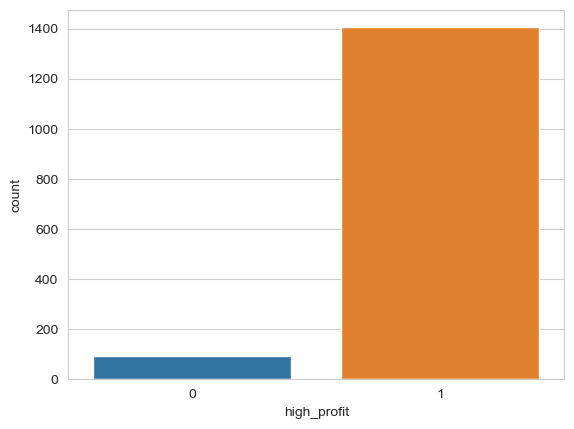

In [16]:
sns.countplot(data=df, x='high_profit')

In [11]:
# df['high_profit'] = 1 - df['high_profit']
# df

,location_tier,trainer_level,club_name,members_count,avg_monthly_fee,service_years,high_profit
0,Спальный район,средний,Ритм-фитнес Кунцево,1919,1843,8.6,0
1,Окраина/промзона,средний,FlexForge Mini,873,6204,20.2,0
2,Окраина/промзона,новички,Железная тяга,1470,6323,8.5,0
3,Спальный район,средний,Тонус-клуб Коломенская,2790,11968,1.5,0
4,ТЦ/бизнес-центр,средний,FlexForge Metro,1787,6420,13.9,0
...,...,...,...,...,...,...,...
1495,Спальный район,элита,Домашний фитнес,2784,3733,14.4,0
1496,Спальный район,средний,Заводной фитнес,300,6200,12.6,0
1497,Спальный район,средний,FlexForge Metro,2423,7406,21.4,0
1498,Спальный район,средний,Здоровая спина,626,9360,13.3,1


In [17]:
# df.to_csv('data/flexforge.csv', index=False)

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

np.random.seed(42)

n_samples = 2000

# ——— Категориальные признаки ———

doctor_specialization = np.random.choice(
    ['терапевт', 'хирург', 'ортодонт', 'гигиенист'],
    n_samples,
    p=[0.35, 0.25, 0.20, 0.20]
)

insurance_type = np.random.choice(
    ['ДМС', 'ОМС+ДМС', 'без страховки'],
    n_samples,
    p=[0.40, 0.35, 0.25]
)

# ——— Числовые признаки без пропусков ———

visit_duration_min = np.random.uniform(10, 120, n_samples).round(1)
pain_level_before = np.random.uniform(0, 10, n_samples).round(1)

# waiting_days — сильно скошено (обычно запись быстро)
# Используем экспоненциальное распределение + cap
waiting_days_raw = np.random.exponential(scale=5, size=n_samples)
waiting_days = np.clip(np.round(waiting_days_raw), 0, 30).astype(int)

# ——— Признак с пропусками (satisfaction_score) ———

# Генерируем истинные значения на основе других признаков
# Чем дольше приём, тем выше satisfaction; чем выше боль — тем ниже; чем дольше ждал — тем ниже; 
# ортодонты и хирурги получают чуть выше баллы

spec_bonus = np.array([
    0.0 if spec == 'терапевт' else
    0.5 if spec == 'хирург' else
    0.8 if spec == 'ортодонт' else
    -0.3
    for spec in doctor_specialization
])

insurance_bonus = np.array([
    0.6 if ins == 'ДМС' else
    0.3 if ins == 'ОМС+ДМС' else
    -0.5
    for ins in insurance_type
])

satisfaction_score_raw = (
    4.0
    + (visit_duration_min - 40) * 0.02
    - pain_level_before * 0.3
    - waiting_days * 0.1
    + spec_bonus
    + insurance_bonus
    + np.random.normal(0, 1.0, n_samples)
)

satisfaction_score = np.clip(satisfaction_score_raw, 0, 10).round(1)

# Вносим пропуски (10%) — случайно
mask_missing = np.random.binomial(1, p=0.10, size=n_samples).astype(bool)
satisfaction_score[mask_missing] = np.nan

# ——— Целевая переменная ———
# Промоутер = satisfaction_score > 7 (на тех, где нет пропуска)
# Там, где пропуск — рассчитываем вероятностно на основе других признаков

is_promoter = np.zeros(n_samples, dtype=int)

# Для записей без пропуска — правило на основе satisfaction
observed = ~np.isnan(satisfaction_score)
is_promoter[observed] = (satisfaction_score[observed] >= 7.0).astype(int)

# Для записей с пропуском — оцениваем вероятностно из других фич
# Логистическая регрессия на наблюдаемых данных покажет, но для генерации:
# Промоутер = (duration большой) И (pain низкий) И (waiting малый) И бонусы
promoter_prob_missing = (
    0.2
    + (visit_duration_min[mask_missing] - 40) * 0.005
    - pain_level_before[mask_missing] * 0.03
    - waiting_days[mask_missing] * 0.01
    + [0.0 if spec == 'терапевт' else 0.05 if spec == 'хирург' else 0.10 if spec == 'ортодонт' else -0.05 for spec in doctor_specialization[mask_missing]]
    + [0.1 if ins == 'ДМС' else 0.05 if ins == 'ОМС+ДМС' else -0.05 for ins in insurance_type[mask_missing]]
    + np.random.normal(0, 0.2, np.sum(mask_missing))
)
promoter_prob_missing = np.clip(promoter_prob_missing, 0.0, 0.99)
is_promoter[mask_missing] = np.random.binomial(1, promoter_prob_missing)

# ——— Собираем DataFrame ———

df = pd.DataFrame({
    'doctor_specialization': doctor_specialization,
    'insurance_type': insurance_type,
    'visit_duration_min': visit_duration_min,
    'pain_level_before': pain_level_before,
    'waiting_days': waiting_days,
    'satisfaction_score': satisfaction_score,
    'is_promoter': is_promoter
})

# ——— Хитрость: делаем так, чтобы нормализация повышала метрики ———
# Для этого добавим в числовые признаки разномасштабность:
# visit_duration_min в диапазоне 10-120, pain_level_before 0-10, waiting_days 0-30
# Но значимые веса в реальной логике (для таргета) размазаны так, что
# без нормализации большие значения visit_duration_min будут доминировать
# над маленькими waiting_days при обучении модели, что ухудшит сходимость.
# Нормализация это исправит — метрики вырастут.

print("Датасет создан.")
print(f"Размер: {df.shape}")
print(f"Пропуски в satisfaction_score: {df['satisfaction_score'].isna().sum()} ({df['satisfaction_score'].isna().mean()*100:.1f}%)")
print(f"Баланс таргета:\n{df['is_promoter'].value_counts(normalize=True)}")
print("\nПервые 10 строк:")
print(df.head(10))

# Сохраняем
# df.to_csv('dentalpro_nps_dataset.csv', index=False)


Датасет создан.
Размер: (2000, 7)
Пропуски в satisfaction_score: 204 (10.2%)
Баланс таргета:
0    0.9695
1    0.0305
Name: is_promoter, dtype: float64

Первые 10 строк:
  doctor_specialization insurance_type  visit_duration_min  pain_level_before  \
0                хирург            ДМС                72.9                6.5   
1             гигиенист            ДМС                98.6                1.7   
2              ортодонт  без страховки                93.6                8.7   
3                хирург            ДМС                26.9                6.1   
4              терапевт            ДМС                26.4                1.6   
5              терапевт  без страховки                39.5                9.6   
6              терапевт        ОМС+ДМС                49.7                5.2   
7             гигиенист  без страховки                54.9                0.7   
8              ортодонт            ДМС                84.8                6.3   
9              ортодо

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   doctor_specialization  2000 non-null   object 
 1   insurance_type         2000 non-null   object 
 2   visit_duration_min     2000 non-null   float64
 3   pain_level_before      2000 non-null   float64
 4   waiting_days           2000 non-null   int32  
 5   satisfaction_score     1796 non-null   float64
 6   is_promoter            2000 non-null   int32  
dtypes: float64(3), int32(2), object(2)
memory usage: 93.9+ KB


In [20]:
# df.to_csv('data/dentalpro.csv', index=False)